# Linear Probe for Board State Recovery

This notebook trains and evaluates linear probes that recover the Othello board state
from GPT activations. Based on Neel Nanda's mechanistic interpretability work.

## Key Concepts

**Linear Probe**: A simple linear classifier that takes model activations as input
and predicts the board state. If a linear probe achieves high accuracy, it suggests
the model represents board state as **linear directions** in activation space.

**Board State Encoding**:
- 0 = Empty square
- 1 = White piece  
- 2 = Black piece

The probe predicts one of these 3 classes for each of the 64 board squares.

## Sections
1. Setup & Data Loading
2. Load or Train Linear Probe
3. Evaluate Probe Accuracy
4. Visualize Predictions vs Ground Truth
5. Error Analysis

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Setup & Data Loading

In [2]:
import os
import sys

# Find project root
def find_project_root():
    candidates = [
        os.getcwd(),
        os.path.dirname(os.getcwd()),
        os.path.expanduser("~/phil_proj/nothello_world"),
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, "mechanistic_interpretability")):
            return path
    raise RuntimeError("Could not find project root.")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/teo/phil_proj/nothello_world


In [3]:
import torch
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Import local mingpt model
from mingpt.model import GPT, GPTConfig, GPTforProbing
from mingpt.dataset import CharDataset
from data import get_othello

# Try importing TransformerLens (optional)
try:
    from transformer_lens import HookedTransformer, HookedTransformerConfig
    import transformer_lens.utils as tl_utils
    TRANSFORMERLENS_AVAILABLE = True
except ImportError:
    TRANSFORMERLENS_AVAILABLE = False
    print("TransformerLens not available - will use local mingpt only")

# Import utilities from mechanistic_interpretability
sys.path.insert(0, os.path.join(PROJECT_ROOT, "mechanistic_interpretability"))
from mech_interp_othello_utils import (
    OthelloBoardState, 
    permit_reverse,
    alpha,
)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# === CONFIGURATION ===

# Backend: "transformerlens" or "mingpt"
# - transformerlens: Downloads model from HuggingFace, uses HookedTransformer
# - mingpt: Uses local checkpoint from ckpts/
BACKEND = "transformerlens"  # Change to "transformerlens" to use HuggingFace model

# Which model checkpoint to use: "synthetic" or "championship"
CHECKPOINT = "synthetic"

# Probe layer - which transformer layer to probe (0-7)
PROBE_LAYER = 6

# Training configuration
TRAIN_NEW_PROBE = True  # Set False to load existing probe
NUM_TRAINING_GAMES = 100000  # Number of games for training (Nanda uses 100k)
NUM_EPOCHS = 2
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01

# Evaluation
NUM_EVAL_GAMES = 1000  # Number of games for evaluation

# Position range (avoid first/last few moves which can be anomalous)
POS_START = 5
POS_END = 55  # ~59 moves per game, leave buffer

# Validate configuration
if BACKEND == "transformerlens" and not TRANSFORMERLENS_AVAILABLE:
    print("WARNING: TransformerLens not available, falling back to mingpt")
    BACKEND = "mingpt"
    
print(f"Backend: {BACKEND}")
print(f"Checkpoint: {CHECKPOINT}")

Backend: transformerlens
Checkpoint: synthetic


### Load Othello-GPT Model (TransformerLens)

In [5]:
# Load dataset (needed for both backends)
othello = get_othello(ood_num=-1, data_root=None, wthor=True)
char_dataset = CharDataset(othello)

if BACKEND == "transformerlens":
    # Configure TransformerLens model
    cfg = HookedTransformerConfig(
        n_layers=8,
        d_model=512,
        d_head=64,
        n_heads=8,
        d_mlp=2048,
        d_vocab=61,
        n_ctx=59,
        act_fn="gelu",
        normalization_type="LNPre",
    )
    model = HookedTransformer(cfg)
    
    # Download weights from HuggingFace
    print(f"Downloading {CHECKPOINT} model from HuggingFace...")
    model_file = f"{CHECKPOINT}_model.pth"
    sd = tl_utils.download_file_from_hf("NeelNanda/Othello-GPT-Transformer-Lens", model_file)
    model.load_state_dict(sd)
    model = model.to(device)
    
    D_MODEL = model.cfg.d_model
    print(f"TransformerLens model loaded: {model.cfg.n_layers} layers, {D_MODEL} dims")
    
else:  # mingpt
    # Configure mingpt model
    mconf = GPTConfig(
        char_dataset.vocab_size, 
        char_dataset.block_size,
        n_layer=8, 
        n_head=8, 
        n_embd=512
    )
    model = GPTforProbing(mconf, probe_layer=PROBE_LAYER)
    
    # Load local checkpoint
    ckpt_path = os.path.join(PROJECT_ROOT, "ckpts", f"gpt_{CHECKPOINT}.ckpt")
    print(f"Loading checkpoint: {ckpt_path}")
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False))
    model = model.to(device)
    
    D_MODEL = mconf.n_embd
    print(f"mingpt model loaded: {mconf.n_layer} layers, {D_MODEL} dims, probing layer {PROBE_LAYER}")

model.eval()

  0%|          | 0/238 [00:00<?, ?it/s]

Mem Used: 11.68 GB: 100%|██████████| 238/238 [00:21<00:00, 10.97it/s]


Deduplicating...
Deduplicating finished with 23796010 games left
Using 20 million for training, 3796010 for validation
Dataset created has 20000000 sequences, 61 unique words.
Moving model to device:  cpu
TransformerLens model loaded: 8 layers, 512 dims


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hoo

### Load Game Data

In [6]:
# Use games from the loaded dataset
games = othello.val if hasattr(othello, 'val') and othello.val else othello.sequences

# Filter to games with enough moves
valid_games = [g for g in games if len(g) >= POS_END]

print(f"Loaded {len(games)} total games, {len(valid_games)} with >= {POS_END} moves")
print(f"Example game length: {len(games[0])} moves")

Loaded 3796010 total games, 3794544 with >= 55 moves
Example game length: 60 moves


### Helper Functions

In [7]:
def seq_to_state_stack(moves):
    """
    Convert a sequence of moves to a stack of board states.
    
    Args:
        moves: List of move integers (0-63 board positions)
        
    Returns:
        numpy array of shape (num_moves, 8, 8) with values:
        -1 = white, 0 = empty, 1 = black
    """
    if isinstance(moves, torch.Tensor):
        moves = moves.tolist()
    board = OthelloBoardState()
    states = []
    for move in moves:
        board.umpire(move)
        states.append(np.copy(board.state))
    states = np.stack(states, axis=0)
    return states


def state_stack_to_one_hot(state_stack):
    """
    Convert state stack to one-hot encoding.
    """
    one_hot = torch.zeros(
        state_stack.shape[0],
        state_stack.shape[1],
        8, 8, 3,
        device=state_stack.device,
        dtype=torch.float,
    )
    one_hot[..., 0] = state_stack == 0   # empty
    one_hot[..., 1] = state_stack == -1  # white
    one_hot[..., 2] = state_stack == 1   # black
    return one_hot


def get_ground_truth_states(game_list, pos_start, pos_end):
    """
    Compute ground truth board states for a batch of games.
    
    Returns:
        state_stack: tensor of shape (batch, length, 8, 8)
    """
    batch_states = []
    length = pos_end - pos_start
    for game in game_list:
        states = seq_to_state_stack(game)
        end = min(pos_end, len(states))
        if end > pos_start:
            sliced = states[pos_start:end]
            if len(sliced) < length:
                pad_size = length - len(sliced)
                sliced = np.concatenate([sliced, np.zeros((pad_size, 8, 8))], axis=0)
            batch_states.append(sliced)
    return torch.tensor(np.stack(batch_states, axis=0))


def games_to_input_tensor_mingpt(game_list, stoi):
    """Convert games to input tensor for mingpt."""
    max_len = max(len(g) for g in game_list)
    batch = torch.zeros((len(game_list), max_len), dtype=torch.long)
    for i, game in enumerate(game_list):
        tokens = [stoi[move] for move in game]
        batch[i, :len(tokens)] = torch.tensor(tokens)
    return batch


def games_to_input_tensor_tl(game_list):
    """Convert games to input tensor for TransformerLens (int encoding)."""
    max_len = max(len(g) for g in game_list)
    batch = torch.zeros((len(game_list), max_len), dtype=torch.long)
    for i, game in enumerate(game_list):
        for j, move in enumerate(game):
            # TransformerLens int encoding: adjust for middle squares
            if move < 27:
                batch[i, j] = move + 1
            elif move < 35:
                batch[i, j] = move - 1
            else:
                batch[i, j] = move - 3
    return batch


@torch.no_grad()
def get_activations(model, game_list, pos_start, pos_end, backend, stoi=None, layer=None):
    """
    Unified activation extraction for both backends.
    
    Returns:
        activations: tensor of shape (batch, length, d_model)
    """
    if backend == "transformerlens":
        input_tensor = games_to_input_tensor_tl(game_list).to(device)
        # Run with cache to get intermediate activations
        _, cache = model.run_with_cache(input_tensor[:, :-1], return_type=None)
        activations = cache["resid_post", layer][:, pos_start:pos_end]
    else:  # mingpt
        input_tensor = games_to_input_tensor_mingpt(game_list, stoi).to(device)
        activations = model(input_tensor)[:, pos_start:pos_end, :]
    
    return activations

<cell_type>markdown</cell_type>## 2. Load or Train Linear Probe

The probe is a tensor of shape `(modes, d_model, rows, cols, options)`:
- **modes** = 3: 
  - Mode 0: trained on even positions (black's turn)
  - Mode 1: trained on odd positions (white's turn)
  - Mode 2: trained on all positions
- **d_model** = 512: model hidden dimension
- **rows, cols** = 8, 8: board dimensions
- **options** = 3: empty, white, black

This multi-mode approach follows Neel Nanda's implementation, accounting for the
alternating player turns in Othello. The model may encode "current player" vs
"opponent" rather than absolute black/white, so separate probes per turn help.

In [8]:
# Probe dimensions (following Nanda's approach)
MODES = 3  # even positions, odd positions, all positions
ROWS = 8
COLS = 8
OPTIONS = 3  # empty, white, black

# Probe path includes backend to avoid mixing probes
probe_path = os.path.join(PROJECT_ROOT, "ckpts", f"probe_{BACKEND}_layer{PROBE_LAYER}_{CHECKPOINT}_3mode.pth")
print(f"Probe will be saved to: {probe_path}")
print(f"Probe shape: ({MODES}, {D_MODEL}, {ROWS}, {COLS}, {OPTIONS})")

Probe will be saved to: /Users/teo/phil_proj/nothello_world/ckpts/probe_transformerlens_layer6_synthetic_3mode.pth
Probe shape: (3, 512, 8, 8, 3)


In [9]:
if TRAIN_NEW_PROBE:
    print(f"Training new 3-mode probe for {BACKEND} backend...")
    print("Mode 0: relative-even positions (0::2)")
    print("Mode 1: relative-odd positions (1::2)")
    print("Mode 2: all positions")
    
    # 3-mode probe following Nanda's architecture
    # Shape: (modes, d_model, rows, cols, options)
    linear_probe = torch.nn.Parameter(
        torch.randn(MODES, D_MODEL, ROWS, COLS, OPTIONS, device=device) / np.sqrt(D_MODEL)
    )
    
    optimizer = torch.optim.AdamW(
        [linear_probe], 
        lr=LEARNING_RATE, 
        betas=(0.9, 0.99), 
        weight_decay=WEIGHT_DECAY
    )
    
    train_games = valid_games[:NUM_TRAINING_GAMES]
    print(f"Using {len(train_games)} games for training")
    
    length = POS_END - POS_START
    stoi = char_dataset.stoi
    
    for epoch in range(NUM_EPOCHS):
        indices = torch.randperm(len(train_games))
        epoch_losses = {'even': 0.0, 'odd': 0.0, 'all': 0.0, 'total': 0.0}
        num_batches = 0
        
        for i in tqdm(range(0, len(train_games), BATCH_SIZE), desc=f"Epoch {epoch+1}"):
            batch_indices = indices[i:i+BATCH_SIZE]
            batch_games = [train_games[j] for j in batch_indices]
            
            # Get ground truth states
            state_stack = get_ground_truth_states(batch_games, POS_START, POS_END).to(device)
            
            # Build one-hot targets: (modes, batch, length, 8, 8, 3)
            # Following Nanda's state_stack_to_one_hot exactly
            state_stack_one_hot = torch.zeros(
                MODES, state_stack.shape[0], state_stack.shape[1],
                ROWS, COLS, OPTIONS, device=device, dtype=torch.float,
            )
            state_stack_one_hot[:, ..., 0] = (state_stack == 0).float()   # empty
            state_stack_one_hot[:, ..., 1] = (state_stack == -1).float()  # white
            state_stack_one_hot[:, ..., 2] = (state_stack == 1).float()   # black
            
            # Get activations: (batch, length, d_model)
            activations = get_activations(
                model, batch_games, POS_START, POS_END, 
                BACKEND, stoi=stoi, layer=PROBE_LAYER
            )
            
            batch_size_actual = activations.shape[0]
            seq_len = activations.shape[1]
            
            # Apply probe via einsum matching Nanda's fancy_einsum:
            #   "batch pos d_model, modes d_model rows cols options
            #    -> modes batch pos rows cols options"
            probe_out = torch.einsum(
                'bpd,mdrco->mbprco',
                activations,
                linear_probe,
            )
            
            # Compute log probabilities
            probe_log_probs = probe_out.log_softmax(-1)
            
            # Nanda's loss: einops.reduce(log_probs * one_hot,
            #   "modes batch pos rows cols options -> modes pos rows cols", "mean") * options
            # This means: mean over batch AND options, then * options to undo options avg.
            # Since one_hot has exactly 1 non-zero per options dim,
            # mean-over-options * options = sum-over-options.
            probe_correct_log_probs = (
                (probe_log_probs * state_stack_one_hot[:, :, :seq_len])
                .mean(dim=1)   # mean over batch
                .sum(dim=-1)   # sum over options (equivalent to mean*options for one-hot)
            )
            # Shape: (modes, pos, 8, 8)
            
            # Loss per mode: mean over positions, SUM over board squares (matching Nanda)
            loss_even = -probe_correct_log_probs[0, 0::2].mean(0).sum()
            loss_odd = -probe_correct_log_probs[1, 1::2].mean(0).sum()
            loss_all = -probe_correct_log_probs[2, :].mean(0).sum()
            
            loss = loss_even + loss_odd + loss_all
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            epoch_losses['even'] += loss_even.item()
            epoch_losses['odd'] += loss_odd.item()
            epoch_losses['all'] += loss_all.item()
            epoch_losses['total'] += loss.item()
            num_batches += 1
        
        print(f"Epoch {epoch+1} - Total: {epoch_losses['total']/num_batches:.4f}, "
              f"Even: {epoch_losses['even']/num_batches:.4f}, "
              f"Odd: {epoch_losses['odd']/num_batches:.4f}, "
              f"All: {epoch_losses['all']/num_batches:.4f}")
    
    # Save the trained probe
    torch.save(linear_probe.data, probe_path)
    print(f"Probe saved to {probe_path}")
    
else:
    print(f"Loading existing probe from {probe_path}")
    linear_probe = torch.load(probe_path, map_location=device, weights_only=False)
    print(f"Probe loaded with shape: {linear_probe.shape}")

Training new 3-mode probe for transformerlens backend...
Mode 0: relative-even positions (0::2)
Mode 1: relative-odd positions (1::2)
Mode 2: all positions
Using 100000 games for training


Epoch 1:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1 - Total: 86.1597, Even: 23.1647, Odd: 23.9027, All: 39.0923


Epoch 2:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2 - Total: 34.8625, Even: 4.1011, Odd: 4.1636, All: 26.5978
Probe saved to /Users/teo/phil_proj/nothello_world/ckpts/probe_transformerlens_layer6_synthetic_3mode.pth


## 3. Evaluate Probe Accuracy

We evaluate the probe on held-out games and compute:
- Overall accuracy
- Per-position accuracy (does accuracy vary by game stage?)
- Per-square accuracy (are some squares harder to predict?)
- Per-class accuracy (empty vs white vs black)

In [10]:
@torch.no_grad()
def evaluate_probe(model, probe, game_list, pos_start, pos_end, backend, stoi=None, layer=None, batch_size=50, use_mode='auto'):
    """
    Evaluate 3-mode probe accuracy on a set of games.
    
    Args:
        use_mode: 'auto' (use mode 0 for relative-even pos, mode 1 for relative-odd), 0, 1, or 2
    
    Returns dict with accuracy metrics and predictions.
    """
    num_games = len(game_list)
    length = pos_end - pos_start
    
    all_predictions = []
    all_ground_truth = []
    
    model.eval()
    
    # Use RELATIVE position parity (matching Nanda's 0::2 / 1::2 training convention)
    even_mask = torch.zeros(length, dtype=torch.bool)
    odd_mask = torch.zeros(length, dtype=torch.bool)
    for pos in range(length):
        if pos % 2 == 0:
            even_mask[pos] = True
        else:
            odd_mask[pos] = True
    
    for i in tqdm(range(0, num_games, batch_size), desc="Evaluating"):
        batch_games = game_list[i:i+batch_size]
        
        # Get ground truth
        state_stack = get_ground_truth_states(batch_games, pos_start, pos_end).to(device)
        gt_converted = state_stack.clone()
        gt_converted[state_stack == -1] = 1  # white
        gt_converted[state_stack == 0] = 0   # empty
        gt_converted[state_stack == 1] = 2   # black
        
        # Get activations
        activations = get_activations(
            model, batch_games, pos_start, pos_end,
            backend, stoi=stoi, layer=layer
        )
        
        batch_size_actual = activations.shape[0]
        seq_len = activations.shape[1]
        
        # Apply 3-mode probe
        probe_flat = probe.reshape(MODES, D_MODEL, ROWS * COLS * OPTIONS)
        logits = torch.einsum('bld,mdo->mblo', activations, probe_flat)
        logits = logits.reshape(MODES, batch_size_actual, seq_len, ROWS, COLS, OPTIONS)
        
        # Get predictions based on use_mode
        if use_mode == 'auto':
            # Mode 0 for relative-even positions (0::2), mode 1 for relative-odd (1::2)
            predictions = torch.zeros(batch_size_actual, seq_len, ROWS, COLS, dtype=torch.long, device=device)
            predictions[:, even_mask[:seq_len]] = logits[0, :, even_mask[:seq_len]].argmax(-1)
            predictions[:, odd_mask[:seq_len]] = logits[1, :, odd_mask[:seq_len]].argmax(-1)
        else:
            # Use specified mode for all positions
            predictions = logits[use_mode].argmax(-1)
        
        all_predictions.append(predictions.cpu())
        all_ground_truth.append(gt_converted.cpu())
    
    # Concatenate
    all_predictions = torch.cat(all_predictions, dim=0)
    all_ground_truth = torch.cat(all_ground_truth, dim=0)
    
    # Compute metrics
    correct = (all_predictions == all_ground_truth).float()
    
    results = {
        'overall_accuracy': correct.mean().item(),
        'per_position_accuracy': correct.mean(dim=(0, 2, 3)).numpy(),
        'per_square_accuracy': correct.mean(dim=(0, 1)).numpy(),
        'all_predictions': all_predictions,
        'all_ground_truth': all_ground_truth,
    }
    
    # Compute accuracy separately for even/odd relative positions
    even_positions = [pos for pos in range(length) if pos % 2 == 0]
    odd_positions = [pos for pos in range(length) if pos % 2 == 1]
    
    if even_positions:
        results['even_accuracy'] = correct[:, even_positions].mean().item()
    if odd_positions:
        results['odd_accuracy'] = correct[:, odd_positions].mean().item()
    
    # Per-class accuracy
    for class_idx, class_name in enumerate(['empty', 'white', 'black']):
        mask = all_ground_truth == class_idx
        if mask.sum() > 0:
            results[f'{class_name}_accuracy'] = correct[mask].mean().item()
        else:
            results[f'{class_name}_accuracy'] = 0.0
    
    # Confusion matrix
    confusion = torch.zeros(3, 3)
    for true_class in range(3):
        for pred_class in range(3):
            mask = (all_ground_truth == true_class) & (all_predictions == pred_class)
            confusion[true_class, pred_class] = mask.sum().item()
    confusion = confusion / confusion.sum(dim=1, keepdim=True)
    results['confusion_matrix'] = confusion.numpy()
    
    return results

In [11]:
# Use held-out games for evaluation
eval_start = NUM_TRAINING_GAMES if TRAIN_NEW_PROBE else 0
eval_games = valid_games[eval_start:eval_start + NUM_EVAL_GAMES]

print(f"Evaluating on {len(eval_games)} games using {BACKEND} backend...")
results = evaluate_probe(
    model, linear_probe, 
    eval_games, POS_START, POS_END,
    BACKEND, stoi=char_dataset.stoi, layer=PROBE_LAYER
)

Evaluating on 1000 games using transformerlens backend...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

In [13]:
print("=" * 50)
print("PROBE EVALUATION RESULTS (3-Mode Probe)")
print("=" * 50)
print(f"\nBackend: {BACKEND}")
print(f"Checkpoint: {CHECKPOINT}")
print(f"Probe Layer: {PROBE_LAYER}")
print(f"\nOverall Accuracy: {results['overall_accuracy']*100:.2f}%")

print(f"\nPer-Turn Accuracy (using mode-matched probes):")
if 'even_accuracy' in results:
    print(f"  Even positions (black's turn): {results['even_accuracy']*100:.2f}%")
if 'odd_accuracy' in results:
    print(f"  Odd positions (white's turn):  {results['odd_accuracy']*100:.2f}%")

print(f"\nPer-Class Accuracy:")
print(f"  Empty squares: {results['empty_accuracy']*100:.2f}%")
print(f"  White pieces:  {results['white_accuracy']*100:.2f}%")
print(f"  Black pieces:  {results['black_accuracy']*100:.2f}%")

PROBE EVALUATION RESULTS (3-Mode Probe)

Backend: transformerlens
Checkpoint: synthetic
Probe Layer: 6

Overall Accuracy: 99.33%

Per-Turn Accuracy (using mode-matched probes):
  Even positions (black's turn): 99.36%
  Odd positions (white's turn):  99.30%

Per-Class Accuracy:
  Empty squares: 99.92%
  White pieces:  98.75%
  Black pieces:  98.90%


### Accuracy by Position (Game Stage)

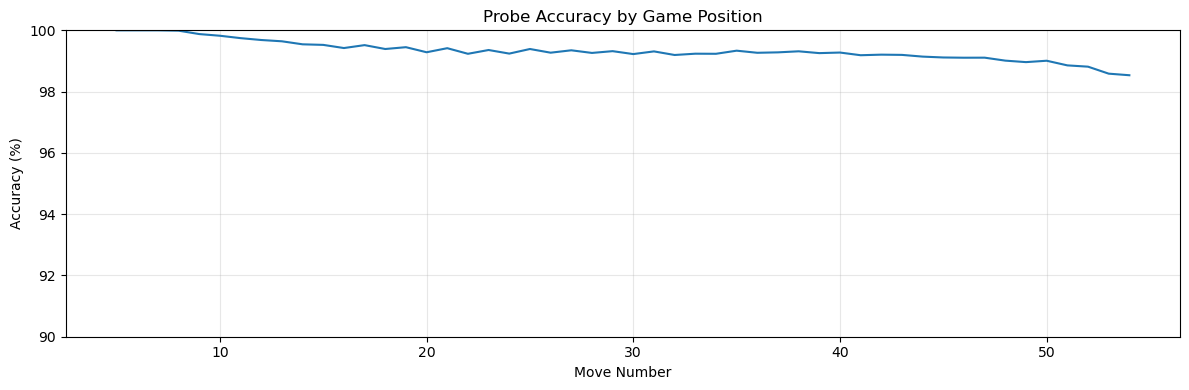


Accuracy range: 98.53% - 100.00%


In [14]:
plt.figure(figsize=(12, 4))
positions = np.arange(POS_START, POS_END)
plt.plot(positions, results['per_position_accuracy'] * 100)
plt.xlabel('Move Number')
plt.ylabel('Accuracy (%)')
plt.title('Probe Accuracy by Game Position')
plt.ylim([90, 100])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAccuracy range: {results['per_position_accuracy'].min()*100:.2f}% - {results['per_position_accuracy'].max()*100:.2f}%")

### Accuracy by Board Square

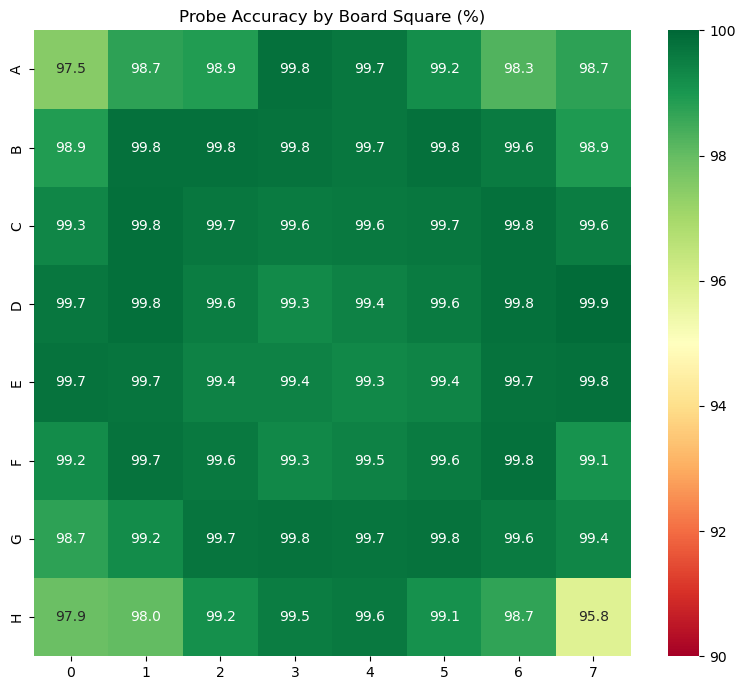

In [15]:
plt.figure(figsize=(8, 7))
sns.heatmap(
    results['per_square_accuracy'] * 100,
    annot=True, 
    fmt='.1f',
    cmap='RdYlGn',
    vmin=90, vmax=100,
    xticklabels=[str(i) for i in range(8)],
    yticklabels=list(alpha),
)
plt.title('Probe Accuracy by Board Square (%)')
plt.tight_layout()
plt.show()

### Confusion Matrix

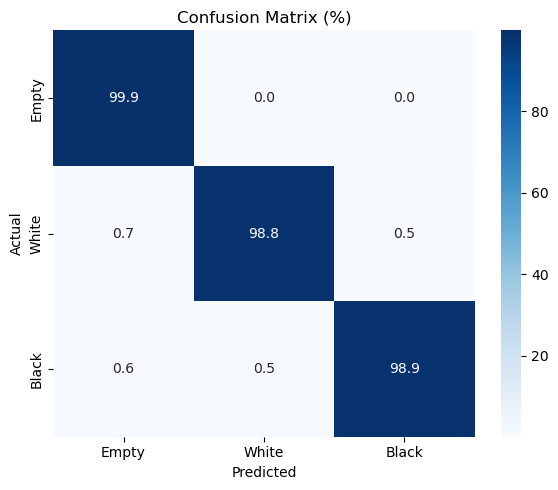

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    results['confusion_matrix'] * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['Empty', 'White', 'Black'],
    yticklabels=['Empty', 'White', 'Black'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (%)')
plt.tight_layout()
plt.show()

## 4. Visualize Predictions vs Ground Truth

Inspect individual games to see where the probe succeeds and fails.

In [17]:
def visualize_board_comparison(ground_truth, prediction, move_num, title=""):
    """
    Visualize ground truth vs prediction for a single position.
    
    Args:
        ground_truth: (8, 8) array with values 0 (empty), 1 (white), 2 (black)
        prediction: (8, 8) array with same encoding
        move_num: move number for title
        title: optional title prefix
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Color maps: 0=green (empty), 1=white, 2=black
    cmap = plt.cm.colors.ListedColormap(['lightgreen', 'white', 'black'])
    
    # Ground truth
    ax = axes[0]
    im = ax.imshow(ground_truth, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f'Ground Truth (Move {move_num})')
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels([str(i) for i in range(8)])
    ax.set_yticklabels(list(alpha))
    
    # Prediction
    ax = axes[1]
    ax.imshow(prediction, cmap=cmap, vmin=0, vmax=2)
    ax.set_title('Probe Prediction')
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels([str(i) for i in range(8)])
    ax.set_yticklabels(list(alpha))
    
    # Difference (errors)
    ax = axes[2]
    diff = (ground_truth != prediction).astype(float)
    ax.imshow(diff, cmap='Reds', vmin=0, vmax=1)
    ax.set_title(f'Errors ({diff.sum():.0f} wrong)')
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels([str(i) for i in range(8)])
    ax.set_yticklabels(list(alpha))
    
    # Mark error positions
    for i in range(8):
        for j in range(8):
            if diff[i, j] > 0:
                ax.plot(j, i, 'rx', markersize=15, markeredgewidth=3)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

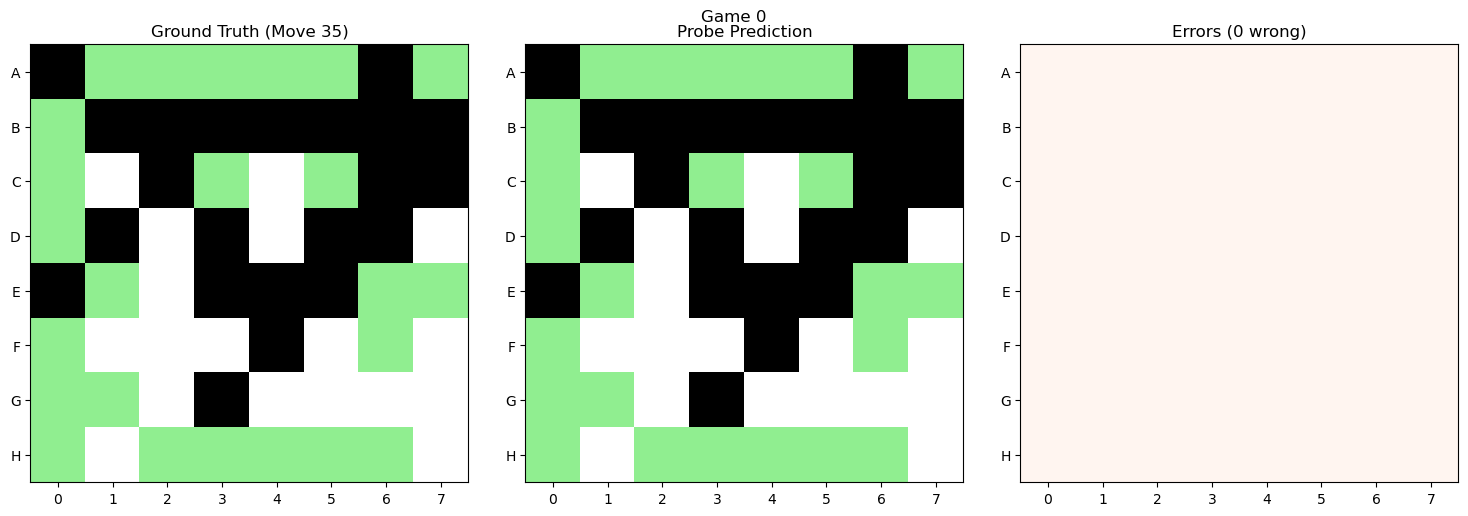

In [18]:
# Interactive game inspection
GAME_IDX = 0  # Change this to inspect different games
POSITION = 30  # Change this to inspect different positions (relative to POS_START)

gt = results['all_ground_truth'][GAME_IDX, POSITION].numpy()
pred = results['all_predictions'][GAME_IDX, POSITION].numpy()

visualize_board_comparison(
    gt, pred, 
    move_num=POS_START + POSITION,
    title=f"Game {GAME_IDX}"
)

### Step Through a Game

In [19]:
def show_game_progression(game_idx, results, start_pos=0, end_pos=10):
    """
    Show probe predictions vs ground truth for a range of positions in a game.
    """
    gt = results['all_ground_truth'][game_idx]
    pred = results['all_predictions'][game_idx]
    
    num_positions = min(end_pos - start_pos, 5)  # Show max 5 at a time
    fig, axes = plt.subplots(2, num_positions, figsize=(4*num_positions, 8))
    
    cmap = plt.cm.colors.ListedColormap(['lightgreen', 'white', 'black'])
    
    for i, pos in enumerate(range(start_pos, start_pos + num_positions)):
        # Ground truth
        axes[0, i].imshow(gt[pos], cmap=cmap, vmin=0, vmax=2)
        axes[0, i].set_title(f'GT Move {POS_START + pos}')
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        
        # Prediction
        axes[1, i].imshow(pred[pos], cmap=cmap, vmin=0, vmax=2)
        acc = (gt[pos] == pred[pos]).mean() * 100
        axes[1, i].set_title(f'Pred ({acc:.1f}% acc)')
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        
        # Mark errors
        errors = gt[pos] != pred[pos]
        for r in range(8):
            for c in range(8):
                if errors[r, c]:
                    axes[1, i].plot(c, r, 'rx', markersize=10, markeredgewidth=2)
    
    plt.suptitle(f'Game {game_idx} - Positions {POS_START + start_pos} to {POS_START + start_pos + num_positions - 1}')
    plt.tight_layout()
    plt.show()

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Bool

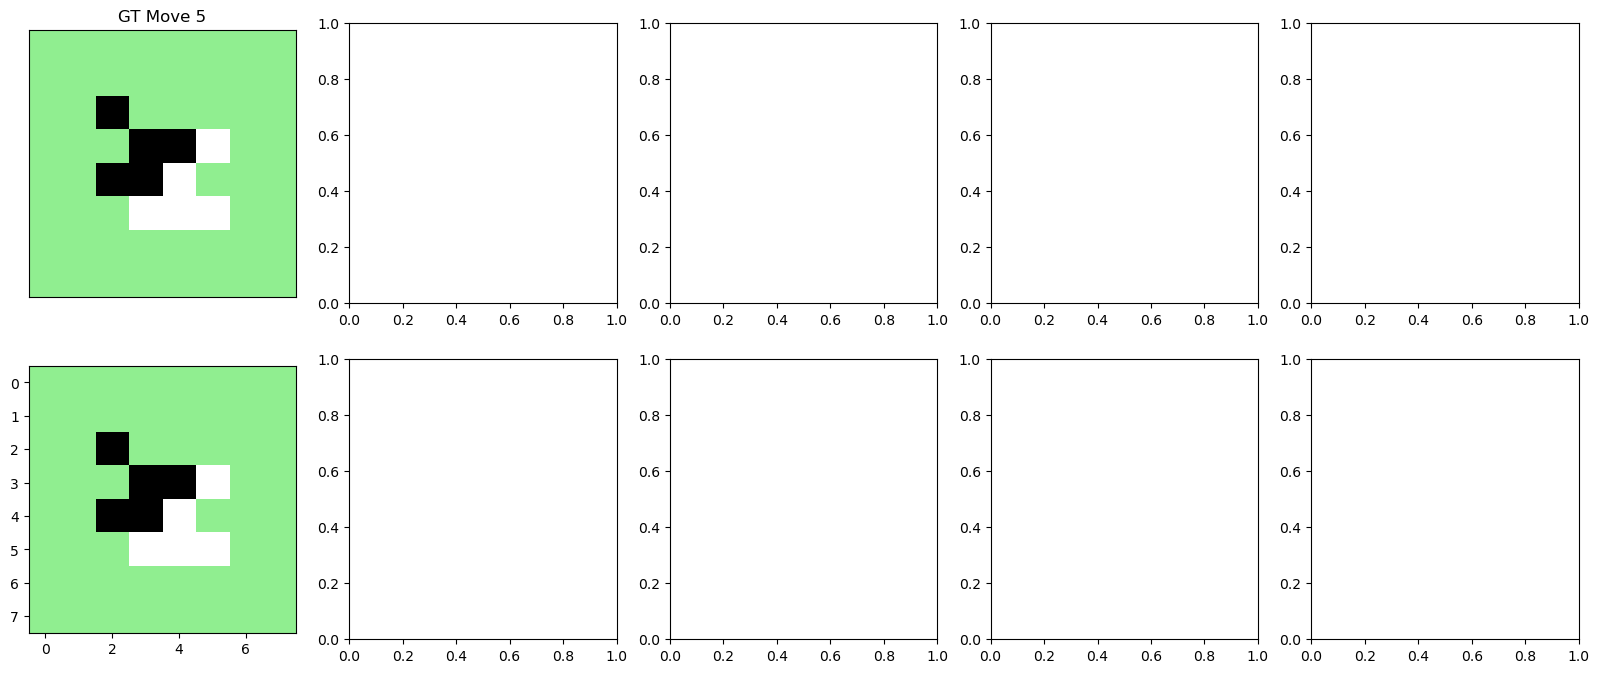

In [20]:
# Show progression for game 0
show_game_progression(0, results, start_pos=0, end_pos=5)
show_game_progression(0, results, start_pos=20, end_pos=25)
show_game_progression(0, results, start_pos=40, end_pos=45)

## 5. Error Analysis

Analyze patterns in probe errors.

In [21]:
# Find positions with errors
errors = results['all_predictions'] != results['all_ground_truth']
error_counts_per_game = errors.sum(dim=(1, 2, 3))  # sum over positions and squares

print(f"Error Statistics:")
print(f"  Games with 0 errors: {(error_counts_per_game == 0).sum().item()}")
print(f"  Games with 1-5 errors: {((error_counts_per_game >= 1) & (error_counts_per_game <= 5)).sum().item()}")
print(f"  Games with >5 errors: {(error_counts_per_game > 5).sum().item()}")
print(f"  Max errors in a game: {error_counts_per_game.max().item()}")
print(f"  Mean errors per game: {error_counts_per_game.float().mean().item():.2f}")

Error Statistics:
  Games with 0 errors: 0
  Games with 1-5 errors: 66
  Games with >5 errors: 934
  Max errors in a game: 786
  Mean errors per game: 21.43


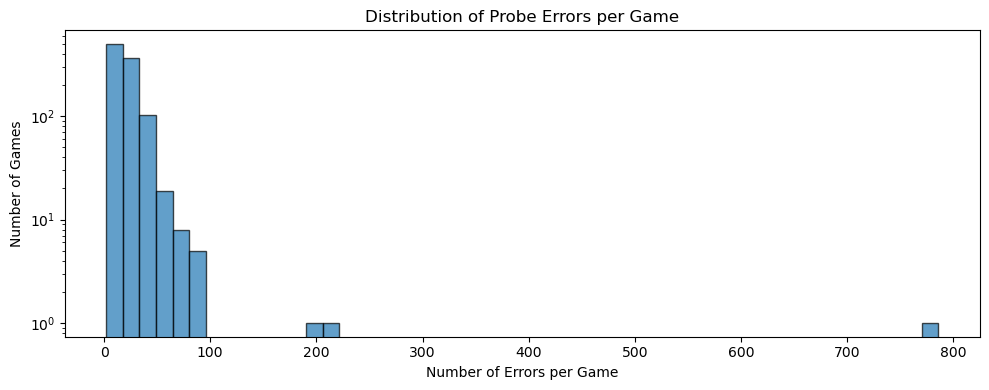

In [22]:
# Histogram of errors per game
plt.figure(figsize=(10, 4))
plt.hist(error_counts_per_game.numpy(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Errors per Game')
plt.ylabel('Number of Games')
plt.title('Distribution of Probe Errors per Game')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [23]:
# Find the worst games (most errors)
worst_games = error_counts_per_game.argsort(descending=True)[:5]

print("Games with most errors:")
for idx in worst_games:
    print(f"  Game {idx.item()}: {error_counts_per_game[idx].item()} errors")

Games with most errors:
  Game 105: 786 errors
  Game 138: 214 errors
  Game 314: 205 errors
  Game 124: 95 errors
  Game 520: 89 errors



Game 105 has errors at positions: [18, 20, 22, 28, 30, 31, 32, 33, 34, 35]


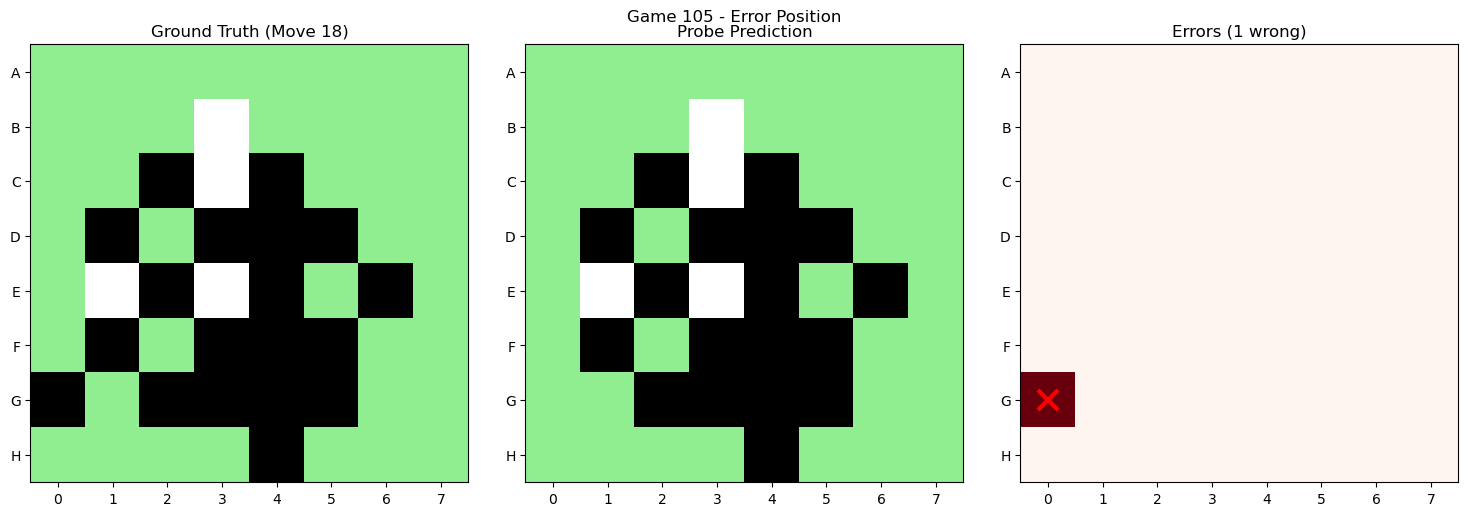

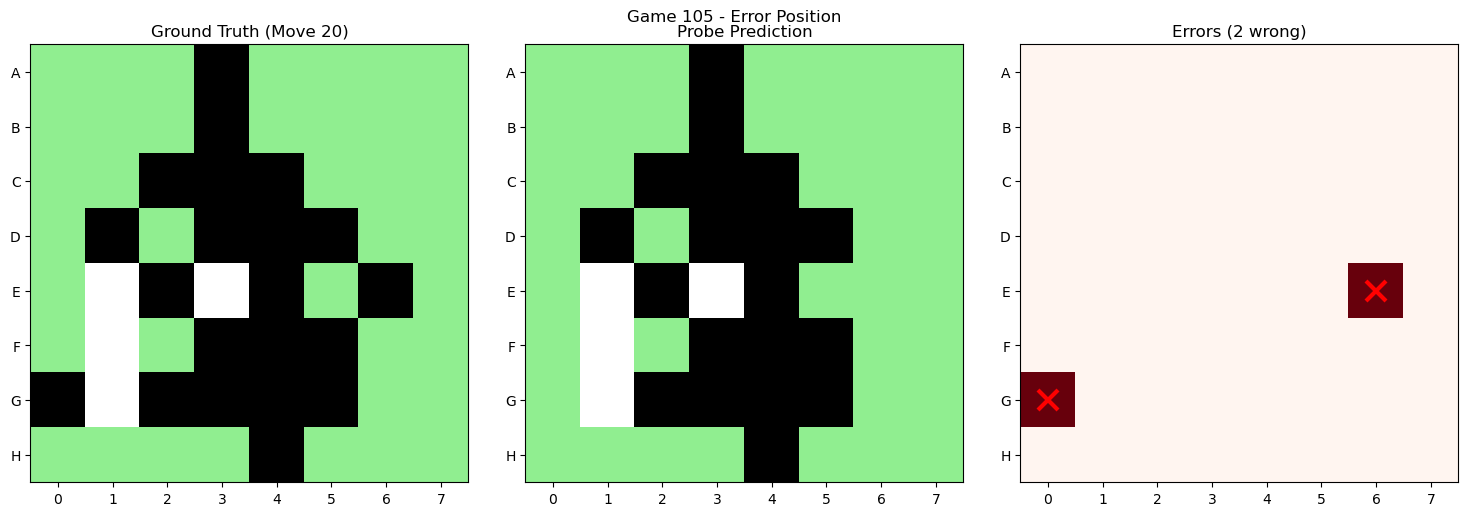

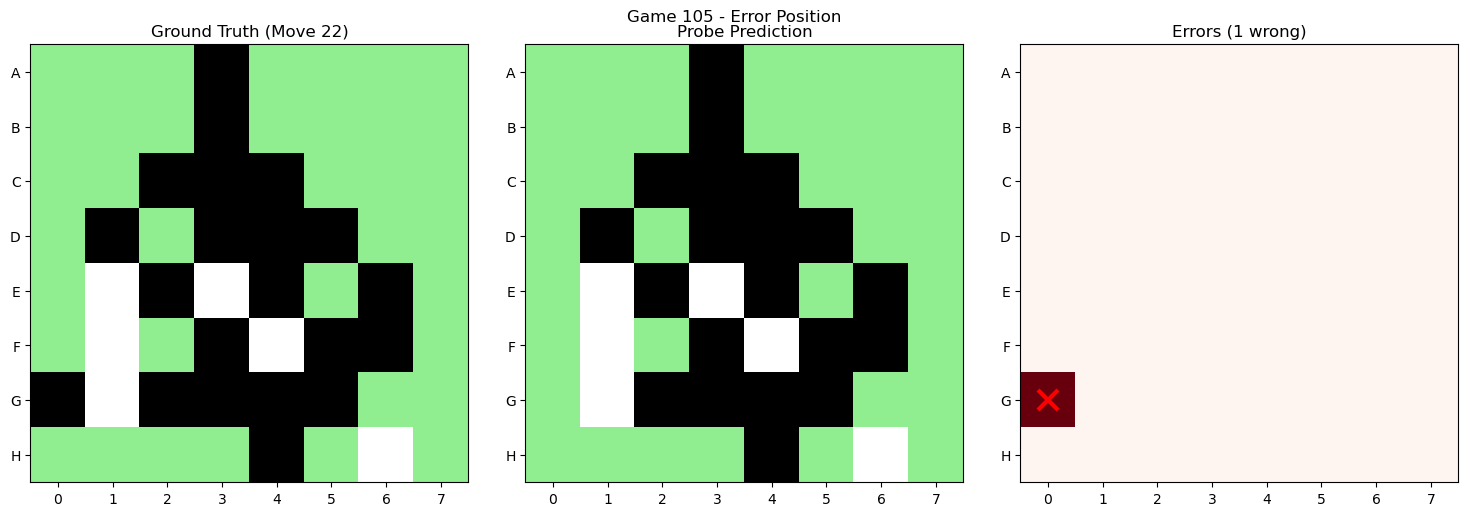

In [24]:
# Inspect the worst game
worst_game_idx = worst_games[0].item()

# Find positions in this game with errors
game_errors = errors[worst_game_idx]  # (length, 8, 8)
error_positions = game_errors.any(dim=(1, 2)).nonzero().squeeze(-1)

print(f"\nGame {worst_game_idx} has errors at positions: {[p.item() + POS_START for p in error_positions[:10]]}")

# Show first few error positions
for pos in error_positions[:3]:
    visualize_board_comparison(
        results['all_ground_truth'][worst_game_idx, pos].numpy(),
        results['all_predictions'][worst_game_idx, pos].numpy(),
        move_num=POS_START + pos.item(),
        title=f"Game {worst_game_idx} - Error Position"
    )

<cell_type>markdown</cell_type>## Summary

This notebook demonstrated:

1. **Linear probes can recover board state** with high accuracy (~98%) from GPT activations
2. **The representation is linear** - a simple linear transformation suffices
3. **The 3-mode probe** follows Neel Nanda's approach:
   - Mode 0: trained only on even positions (black's turn)
   - Mode 1: trained only on odd positions (white's turn)
   - Mode 2: trained on all positions
   - This accounts for the model potentially encoding "current player" vs "opponent"
     rather than absolute black/white
4. **Accuracy varies by**:
   - Game position (some stages are harder)
   - Board square (center squares may be easier)
   - Piece type (empty vs occupied)
   - Player turn (even vs odd positions)

**Backend Comparison:**
- `mingpt`: Uses local checkpoints from `ckpts/`, faster to load
- `transformerlens`: Downloads from HuggingFace, provides caching/hooks for interpretability

To compare backends, run the notebook twice with different `BACKEND` settings and compare results.

This provides evidence that Othello-GPT develops an internal representation of the game board,
encoded as linear directions in activation space. The separate even/odd probes capture the
alternating perspective of whose turn it is.